## Part A - Data Loading and Preprocessing with Scikit-learn

In [ ]:
# Task 1 - Load and Understand the Dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

In [7]:
df = pd.read_csv("hotel_bookings.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [8]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [9]:
df.shape

(119390, 32)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [11]:
df.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [12]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [13]:
y = df["is_canceled"]

In [14]:
print(y.value_counts())

is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [15]:
print(y.value_counts(normalize=True) * 100)

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


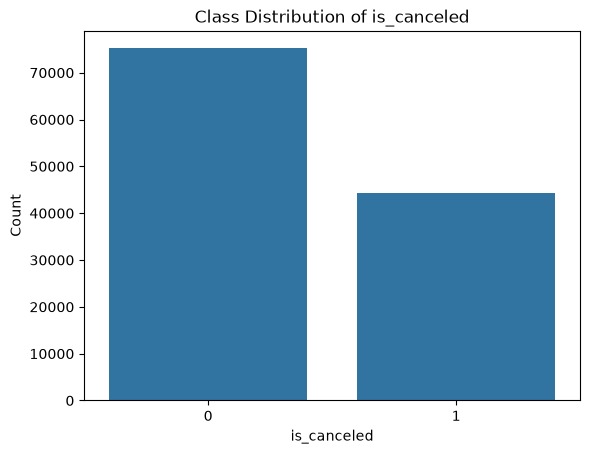

In [16]:
sns.countplot(x=y)
plt.title("Class Distribution of is_canceled")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

In [17]:
X = df.drop(columns=["is_canceled"])

In [18]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\rachi\AppData\Local\Temp\ipykernel_11880\175327131.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [19]:
print("Number of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Number of numerical columns: 19
Number of categorical columns: 12


In [20]:
# Task 2 - Missing Values, Leakage, and Outliers
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [21]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.003350
babies                             0.000000
meal                               0.000000
country                            0.408744
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [22]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


In [23]:
high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

high_missing

,Missing Count,Missing Percentage
company,112593,94.306893


In [24]:
df_clean = df.drop(
    columns=["reservation_status", "reservation_status_date", "company"]
)

In [25]:
df_clean.shape

(119390, 29)

In [26]:
df_clean.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests'],
      dtype='str')

In [27]:
selected_numeric = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "booking_changes",
    "days_in_waiting_list",
    "required_car_parking_spaces",
    "total_of_special_requests"
]

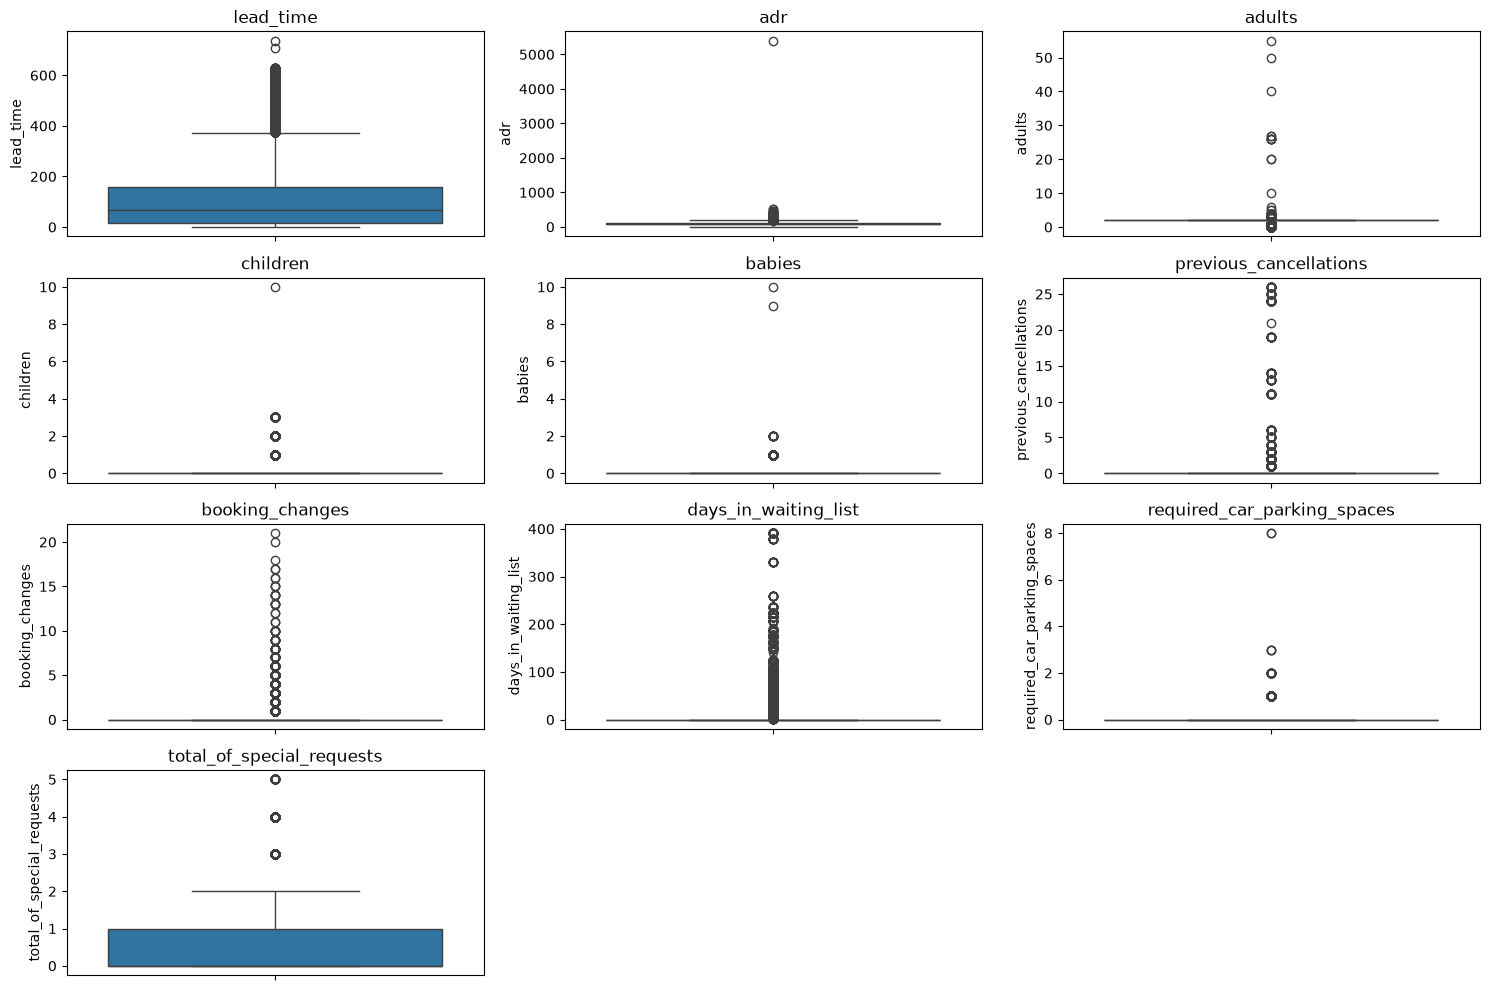

In [28]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(selected_numeric, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df_clean[column])
    plt.title(column)

plt.tight_layout()
plt.show()

In [29]:
for column in selected_numeric:
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ]
    
    print(f"{column}: {len(outliers)} outliers")

lead_time: 3005 outliers
adr: 3793 outliers
adults: 29710 outliers
children: 8590 outliers
babies: 917 outliers
previous_cancellations: 6484 outliers
booking_changes: 18076 outliers
days_in_waiting_list: 3698 outliers
required_car_parking_spaces: 7416 outliers
total_of_special_requests: 2877 outliers


In [30]:
(df_clean["adr"] < 0).sum()

np.int64(1)

In [31]:
df_clean["adr"].max()

np.float64(5400.0)

In [32]:
before_rows = len(df_clean)

df_clean = df_clean[df_clean["adr"] >= 0].copy()

after_rows = len(df_clean)

print("Rows before outlier removal:", before_rows)
print("Rows after outlier removal:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before outlier removal: 119390
Rows after outlier removal: 119389
Rows removed: 1


In [33]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (119390, 32)
Cleaned shape: (119389, 29)


In [34]:
df_clean.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


In [35]:
# Task 3 - Create Two Preprocessing Pipelines
X = df_clean.drop(columns=["is_canceled"])
y = df_clean["is_canceled"]

In [36]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (119389, 28)
y shape: (119389,)


In [37]:
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Number of numerical columns: 18
Number of categorical columns: 10


C:\Users\rachi\AppData\Local\Temp\ipykernel_11880\278557179.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [40]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (95511, 28)
Testing set: (23878, 28)


In [41]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
is_canceled
0    0.629582
1    0.370418
Name: proportion, dtype: float64

Testing target distribution:
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


In [42]:
numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

In [43]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [44]:
preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [45]:
numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

In [46]:
preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [47]:
print("Pipeline A:")
print(preprocessor_A)

print("\nPipeline B:")
print(preprocessor_B)

Pipeline A:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['lead_time', 'arrival_date_year',
                                  'arrival_date_week_number',
                                  'arrival_date_day_of_month',
                                  'stays_in_weekend_nights',
                                  'stays_in_week_nights', 'adults', 'children',
                                  'babies', 'is_repeated_guest',
                                  'previous_cancellations',
                                  'previous_bookings_not_cancel...
                                  'required_car_parking_spaces',
                                  'total_of_special_requests']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                  

## Part B - Model Training and Performance Evaluation

In [49]:
# Task 4 - Train Two Classification Models
logistic_standard = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [50]:
logistic_standard.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [55]:
logistic_minmax = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [56]:
logistic_minmax.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [51]:
tree_standard = Pipeline([
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [52]:
tree_standard.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [53]:
tree_minmax = Pipeline([
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

In [54]:
tree_minmax.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['hotel','lead_time','arrival_date_year',...,'adr', 'required_car_parking_spaces','total_of_special_requests']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By 

In [58]:
# Task 5 - Evaluate and Compare the Four Results
models = {
    "Logistic Regression + StandardScaler": logistic_standard,
    "Logistic Regression + MinMaxScaler": logistic_minmax,
    "Decision Tree + StandardScaler": tree_standard,
    "Decision Tree + MinMaxScaler": tree_minmax
}

In [60]:
y_train_pred_lr_std = logistic_standard.predict(X_train)
y_test_pred_lr_std = logistic_standard.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [61]:
train_accuracy_lr_std = accuracy_score(y_train, y_train_pred_lr_std)
test_accuracy_lr_std = accuracy_score(y_test, y_test_pred_lr_std)
precision_lr_std = precision_score(y_test, y_test_pred_lr_std)
recall_lr_std = recall_score(y_test, y_test_pred_lr_std)
f1_lr_std = f1_score(y_test, y_test_pred_lr_std)

print("Logistic Regression + StandardScaler")
print("Training Accuracy:", train_accuracy_lr_std)
print("Testing Accuracy:", test_accuracy_lr_std)
print("Precision:", precision_lr_std)
print("Recall:", recall_lr_std)
print("F1-Score:", f1_lr_std)

Logistic Regression + StandardScaler
Training Accuracy: 0.8189318507815854
Testing Accuracy: 0.8168188290476589
Precision: 0.8051877133105803
Recall: 0.6668174109666478
F1-Score: 0.7294990723562153


In [62]:
y_train_pred_lr_minmax = logistic_minmax.predict(X_train)
y_test_pred_lr_minmax = logistic_minmax.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [63]:
train_accuracy_lr_minmax = accuracy_score(y_train, y_train_pred_lr_minmax)
test_accuracy_lr_minmax = accuracy_score(y_test, y_test_pred_lr_minmax)
precision_lr_minmax = precision_score(y_test, y_test_pred_lr_minmax)
recall_lr_minmax = recall_score(y_test, y_test_pred_lr_minmax)
f1_lr_minmax = f1_score(y_test, y_test_pred_lr_minmax)

print("Logistic Regression + MinMaxScaler")
print("Training Accuracy:", train_accuracy_lr_minmax)
print("Testing Accuracy:", test_accuracy_lr_minmax)
print("Precision:", precision_lr_minmax)
print("Recall:", recall_lr_minmax)
print("F1-Score:", f1_lr_minmax)

Logistic Regression + MinMaxScaler
Training Accuracy: 0.8135293317000136
Testing Accuracy: 0.8112069687578524
Precision: 0.8018093249826026
Recall: 0.651328434143584
F1-Score: 0.7187772925764192


In [64]:
y_train_pred_tree_std = tree_standard.predict(X_train)
y_test_pred_tree_std = tree_standard.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [65]:
train_accuracy_tree_std = accuracy_score(y_train, y_train_pred_tree_std)
test_accuracy_tree_std = accuracy_score(y_test, y_test_pred_tree_std)
precision_tree_std = precision_score(y_test, y_test_pred_tree_std)
recall_tree_std = recall_score(y_test, y_test_pred_tree_std)
f1_tree_std = f1_score(y_test, y_test_pred_tree_std)

print("Decision Tree + StandardScaler")
print("Training Accuracy:", train_accuracy_tree_std)
print("Testing Accuracy:", test_accuracy_tree_std)
print("Precision:", precision_tree_std)
print("Recall:", recall_tree_std)
print("F1-Score:", f1_tree_std)

Decision Tree + StandardScaler
Training Accuracy: 0.9962203306425438
Testing Accuracy: 0.8612111567132926
Precision: 0.8107652545229801
Recall: 0.8157150932730356
F1-Score: 0.8132326420198377


In [66]:
y_train_pred_tree_minmax = tree_minmax.predict(X_train)
y_test_pred_tree_minmax = tree_minmax.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [67]:
train_accuracy_tree_minmax = accuracy_score(y_train, y_train_pred_tree_minmax)
test_accuracy_tree_minmax = accuracy_score(y_test, y_test_pred_tree_minmax)
precision_tree_minmax = precision_score(y_test, y_test_pred_tree_minmax)
recall_tree_minmax = recall_score(y_test, y_test_pred_tree_minmax)
f1_tree_minmax = f1_score(y_test, y_test_pred_tree_minmax)

print("Decision Tree + MinMaxScaler")
print("Training Accuracy:", train_accuracy_tree_minmax)
print("Testing Accuracy:", test_accuracy_tree_minmax)
print("Precision:", precision_tree_minmax)
print("Recall:", recall_tree_minmax)
print("F1-Score:", f1_tree_minmax)

Decision Tree + MinMaxScaler
Training Accuracy: 0.9962203306425438
Testing Accuracy: 0.861169277158891
Precision: 0.8106741573033708
Recall: 0.8157150932730356
F1-Score: 0.8131868131868132


In [68]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression + StandardScaler",
        "Training Accuracy": train_accuracy_lr_std,
        "Testing Accuracy": test_accuracy_lr_std,
        "Precision": precision_lr_std,
        "Recall": recall_lr_std,
        "F1-Score": f1_lr_std
    },
    {
        "Model": "Logistic Regression + MinMaxScaler",
        "Training Accuracy": train_accuracy_lr_minmax,
        "Testing Accuracy": test_accuracy_lr_minmax,
        "Precision": precision_lr_minmax,
        "Recall": recall_lr_minmax,
        "F1-Score": f1_lr_minmax
    },
    {
        "Model": "Decision Tree + StandardScaler",
        "Training Accuracy": train_accuracy_tree_std,
        "Testing Accuracy": test_accuracy_tree_std,
        "Precision": precision_tree_std,
        "Recall": recall_tree_std,
        "F1-Score": f1_tree_std
    },
    {
        "Model": "Decision Tree + MinMaxScaler",
        "Training Accuracy": train_accuracy_tree_minmax,
        "Testing Accuracy": test_accuracy_tree_minmax,
        "Precision": precision_tree_minmax,
        "Recall": recall_tree_minmax,
        "F1-Score": f1_tree_minmax
    }
])

results_df = results_df.round(4)

results_df

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,Logistic Regression + StandardScaler,0.8189,0.8168,0.8052,0.6668,0.7295
1,Logistic Regression + MinMaxScaler,0.8135,0.8112,0.8018,0.6513,0.7188
2,Decision Tree + StandardScaler,0.9962,0.8612,0.8108,0.8157,0.8132
3,Decision Tree + MinMaxScaler,0.9962,0.8612,0.8107,0.8157,0.8132


In [69]:
results_df["Train-Test Difference"] = (
    results_df["Training Accuracy"] -
    results_df["Testing Accuracy"]
)

results_df.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression + StandardScaler,0.8189,0.8168,0.8052,0.6668,0.7295,0.0021
1,Logistic Regression + MinMaxScaler,0.8135,0.8112,0.8018,0.6513,0.7188,0.0023
2,Decision Tree + StandardScaler,0.9962,0.8612,0.8108,0.8157,0.8132,0.1350
3,Decision Tree + MinMaxScaler,0.9962,0.8612,0.8107,0.8157,0.8132,0.1350


In [70]:
results_sorted = results_df.sort_values(
    by="F1-Score",
    ascending=False
)

results_sorted.round(4)

,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
3,Decision Tree + MinMaxScaler,0.9962,0.8612,0.8107,0.8157,0.8132,0.1350
2,Decision Tree + StandardScaler,0.9962,0.8612,0.8108,0.8157,0.8132,0.1350
0,Logistic Regression + StandardScaler,0.8189,0.8168,0.8052,0.6668,0.7295,0.0021
1,Logistic Regression + MinMaxScaler,0.8135,0.8112,0.8018,0.6513,0.7188,0.0023


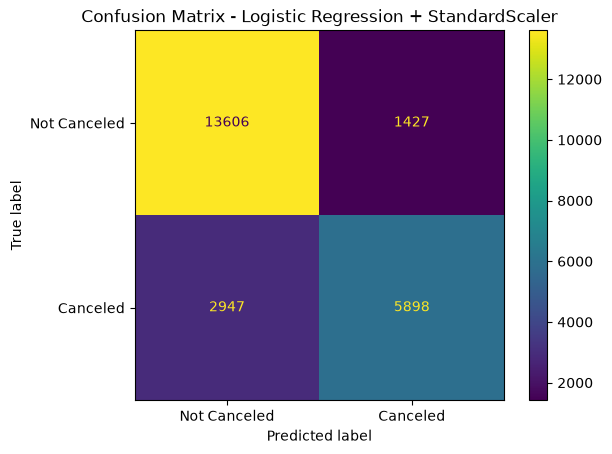

In [71]:
cm_logistic = confusion_matrix(
    y_test,
    y_test_pred_lr_std
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression + StandardScaler")
plt.show()

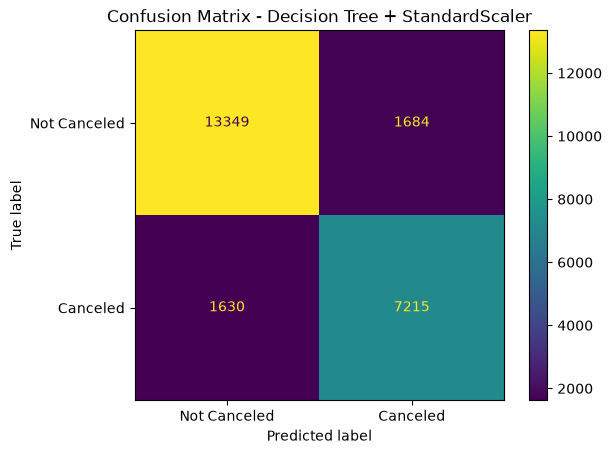

In [72]:
cm_tree = confusion_matrix(
    y_test,
    y_test_pred_tree_std
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree + StandardScaler")
plt.show()

# TASK 6

1. **Decision Tree + StandardScaler gives the best overall result**, with a testing accuracy of 86.12% and an F1-score of 81.32%. Decision Tree + MinMaxScaler produces almost identical results.

2. **StandardScaler performs better than MinMaxScaler for Logistic Regression.** The StandardScaler version achieves 81.68% testing accuracy and an F1-score of 72.95%, compared with 81.12% accuracy and 71.88% F1-score for MinMaxScaler.

3. **Scaling has almost no effect on the Decision Tree.** Both StandardScaler and MinMaxScaler produce 86.12% testing accuracy, 81.57% recall, and 81.32% F1-score. This is expected because decision trees are generally insensitive to feature scaling.

4. **The Decision Tree shows signs of overfitting.** Its training accuracy is 99.62%, while its testing accuracy is only 86.12%, giving a train-test difference of 13.50 percentage points. This indicates that the tree fits the training data very closely but generalizes less effectively to unseen data.

5. **Logistic Regression generalizes more consistently.** The difference between training and testing accuracy is only 0.21 percentage points with StandardScaler and 0.23 percentage points with MinMaxScaler. However, its testing accuracy and F1-score are lower than those of the Decision Tree.
